# Baseline vs eBPF: Split-Aware Detection Experiment

**Research questions addressed:**
> RQ1: Does eBPF monitoring improve malicious traffic detection versus Zeek-only features?  
> RQ5: Does richer context reduce false positives in a meaningful and defensible way?

**Methodological guardrails**
- Split 2 is used only for model-family selection.
- Split 4 realistic is the only headline evaluation and the only result used for downstream headline artifacts.
- Threshold-independent metrics (ROC-AUC, PR-AUC) are reported directly on Split 4 realistic.
- Threshold-dependent headline claims use a validation-defined **matched-recall** operating point so false-positive comparisons are direct rather than inferred from an F1-tuned threshold.
- Splits 1, 3, and Split 4 balanced remain supporting diagnostics only.


In [1]:
import os, sys, json, time, warnings, subprocess
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, accuracy_score,
    average_precision_score, confusion_matrix, RocCurveDisplay,
)
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT, f'Cannot find repo root from {HERE}'
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *

FEATURE_SETS = [
    ('baseline', MODEL_SELECTION_SPLITS_BASELINE, GENERALIZATION_SPLITS_BASELINE),
    ('ebpf',     MODEL_SELECTION_SPLITS_EBPF,     GENERALIZATION_SPLITS_EBPF),
]

SUPPORTING_SPLITS = {
    'split1_group_strat': {
        'role': 'leakage_diagnostic',
        'baseline_dir': SPLITS_1_BASELINE,
        'ebpf_dir': SPLITS_1_EBPF,
        'test_file': 'test.parquet',
    },
    'split2_balanced_quota': {
        'role': 'model_selection',
        'baseline_dir': SPLITS_2_BASELINE,
        'ebpf_dir': SPLITS_2_EBPF,
        'test_file': 'test.parquet',
    },
    'split3_train_resampled': {
        'role': 'resampled_training',
        'baseline_dir': SPLITS_3_BASELINE,
        'ebpf_dir': SPLITS_3_EBPF,
        'test_file': 'test.parquet',
    },
    'split4_balanced': {
        'role': 'balanced_fairness',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_balanced.parquet',
    },
    'split4_realistic': {
        'role': 'headline_generalization',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_realistic.parquet',
    },
}

print('[*] Repo root:', REPO_ROOT)
print('[*] Split 2 model-selection baseline:', MODEL_SELECTION_SPLITS_BASELINE)
print('[*] Split 2 model-selection ebpf    :', MODEL_SELECTION_SPLITS_EBPF)
print('[*] Split 4 headline baseline       :', GENERALIZATION_SPLITS_BASELINE)
print('[*] Split 4 headline ebpf           :', GENERALIZATION_SPLITS_EBPF)
print('[*] Supporting split keys           :', ', '.join(SUPPORTING_SPLITS.keys()))


[*] Repo root: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel
[*] Split 2 model-selection baseline: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_baseline_seed42
[*] Split 2 model-selection ebpf    : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_ebpf_seed42
[*] Split 4 headline baseline       : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed42
[*] Split 4 headline ebpf           : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed42
[*] Supporting split keys           : split1_group_strat, split2_balanced_quota, split3_train_resampled, split4_balanced, split4_realistic


## Helper functions

In [2]:
DROP_COLS = [
    'label_family', 'is_attack', 'day', 'label_raw', 'run_id',
    'ts', 'start_ts', 'end_ts', 't_end', 'orig_h', 'resp_h', 'src_ip', 'dst_ip', 'k',
    'label_time_offset_sec', 'label_halfday_shift_sec',
    'label_window_pre_slop_sec', 'label_window_post_slop_sec',
]

In [3]:
def _numeric_cols(df: pd.DataFrame):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    return [
        c for c in X.columns
        if pd.api.types.is_numeric_dtype(X[c]) and not X[c].isna().all()
    ]

In [4]:
def make_imputer_on_train(train_df: pd.DataFrame, feat: list):
    from sklearn.impute import SimpleImputer
    X_raw = train_df.drop(columns=DROP_COLS, errors='ignore')[feat]
    imp = SimpleImputer(strategy='median')
    imp.fit(X_raw)
    return imp

In [5]:
def prepare_with_imputer(df: pd.DataFrame, feat: list, imputer):
    X_raw = df.drop(columns=DROP_COLS, errors='ignore').copy()
    for c in feat:
        if c not in X_raw.columns:
            X_raw[c] = 0.0
    X_raw = X_raw[feat]
    X_arr = imputer.transform(X_raw)
    X_out = pd.DataFrame(X_arr, columns=feat, index=df.index)
    y = (df['is_attack'] == 1).astype(int).to_numpy()
    labels = df['label_family'].astype(str)
    return X_out, y, labels

In [6]:
def load_split(splits_dir: Path, test_file: str = 'test.parquet'):
    tr = pd.read_parquet(splits_dir / 'train.parquet')
    va = pd.read_parquet(splits_dir / 'val.parquet')
    te = pd.read_parquet(splits_dir / test_file)
    return tr, va, te

In [7]:
def binary_metrics(y_true, y_pred, y_prob=None) -> dict:
    m = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_prob is not None:
        try:
            m['roc_auc'] = float(roc_auc_score(y_true, y_prob))
            m['pr_auc'] = float(average_precision_score(y_true, y_prob))
        except Exception:
            m['roc_auc'] = None
            m['pr_auc'] = None
    return m

In [8]:
def tune_threshold(y_val, y_prob_val):
    from sklearn.metrics import roc_curve
    n_pos = int((y_val == 1).sum())
    if n_pos < 10:
        print(f'    [!] Only {n_pos} validation positives; using threshold=0.5')
        return 0.5
    _, _, thresholds = roc_curve(y_val, y_prob_val)
    f1s = [
        f1_score(y_val, (y_prob_val >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best = float(thresholds[int(np.argmax(f1s))])
    print(f'    Val-tuned threshold: {best:.5f}  (best val F1={max(f1s):.4f})')
    return best

In [9]:
def print_overfit_table(name: str, tr: dict, va: dict, te: dict):
    print(f'\n[*] {name}')
    fmt = '    {split:6s}  acc={accuracy:.4f}  prec={precision:.4f}  rec={recall:.4f}  f1={f1:.4f}  roc_auc={auc}  pr_auc={pr}'
    for split, m in [('train', tr), ('val', va), ('test', te)]:
        print(fmt.format(
            split=split,
            auc=f'{m["roc_auc"]:.4f}' if m.get('roc_auc') is not None else 'N/A',
            pr=f'{m["pr_auc"]:.4f}' if m.get('pr_auc') is not None else 'N/A',
            **{k: v for k, v in m.items() if k not in ('roc_auc', 'pr_auc')},
        ))

In [10]:
def plot_confusion(y_true, y_pred, title: str, out_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm_n, cmap='Blues')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f'{cm[i, j]}\n({cm_n[i, j]:.1%})',
                ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black',
                fontsize=9,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['BENIGN', 'ATTACK'])
    ax.set_yticklabels(['BENIGN', 'ATTACK'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

In [11]:
def fit_hgb_pack(split_dir: Path):
    tr_df = pd.read_parquet(split_dir / 'train.parquet')
    va_df = pd.read_parquet(split_dir / 'val.parquet')
    feat = _numeric_cols(tr_df)
    imp = make_imputer_on_train(tr_df, feat)
    Xtr, ytr, ltr = prepare_with_imputer(tr_df, feat, imp)
    Xva, yva, lva = prepare_with_imputer(va_df, feat, imp)

    clf = HistGradientBoostingClassifier(**HGB_PARAMS)
    t0 = time.time()
    clf.fit(Xtr, ytr)
    fit_seconds = time.time() - t0

    tr_prob = clf.predict_proba(Xtr)[:, 1]
    va_prob = clf.predict_proba(Xva)[:, 1]
    best_thr = tune_threshold(yva, va_prob)

    train_metrics = binary_metrics(ytr, (tr_prob >= best_thr).astype(int), tr_prob)
    val_metrics = binary_metrics(yva, (va_prob >= best_thr).astype(int), va_prob)

    return {
        'model': clf,
        'imputer': imp,
        'features': feat,
        'threshold': best_thr,
        'fit_seconds': fit_seconds,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
    }

In [12]:
def evaluate_hgb_pack(pack: dict, split_dir: Path, test_file: str):
    test_df = pd.read_parquet(split_dir / test_file)
    Xte, yte, lte = prepare_with_imputer(test_df, pack['features'], pack['imputer'])
    te_prob = pack['model'].predict_proba(Xte)[:, 1]
    te_pred = (te_prob >= pack['threshold']).astype(int)
    test_metrics = binary_metrics(yte, te_pred, te_prob)
    return {
        'test_metrics': test_metrics,
        'y_test': yte,
        'y_prob': te_prob,
        'y_pred': te_pred,
        'labels_test': lte,
        'n_rows': len(yte),
        'n_attacks': int(yte.sum()),
    }

In [13]:
def run_hgb_split(fs_name: str, split_name: str, split_dir: Path, test_file: str, *, save_prefix: str | None = None):
    print(f'\n[*] HGB {fs_name} on {split_name} ({test_file})')
    pack = fit_hgb_pack(split_dir)
    ev = evaluate_hgb_pack(pack, split_dir, test_file)
    print_overfit_table(
        f'HGB {fs_name} [{split_name}]',
        pack['train_metrics'], pack['val_metrics'], ev['test_metrics']
    )

    out = {
        'model_path': None,
        'features': pack['features'],
        'threshold': pack['threshold'],
        'fit_seconds': pack['fit_seconds'],
        'train': pack['train_metrics'],
        'val': pack['val_metrics'],
        'test': ev['test_metrics'],
        'y_test': ev['y_test'].tolist(),
        'y_prob': ev['y_prob'].tolist(),
        'y_pred': ev['y_pred'].tolist(),
        'n_rows': ev['n_rows'],
        'n_attacks': ev['n_attacks'],
        'split_name': split_name,
        'test_file': test_file,
    }

    if save_prefix is not None:
        model_path = MODELS_DIR / f'{save_prefix}.joblib'
        joblib.dump(
            {
                'model': pack['model'],
                'imputer': pack['imputer'],
                'features': pack['features'],
                'threshold': pack['threshold'],
                'selected_model_name': 'hgb_balanced',
                'seed': RANDOM_SEED,
                'split_name': split_name,
                'test_file': test_file,
            },
            model_path,
        )
        plot_confusion(
            ev['y_test'], ev['y_pred'],
            f'HGB {fs_name}: {split_name} ({test_file})',
            REPORTS_DIR / f'{save_prefix}_confusion.png',
        )
        out['model_path'] = str(model_path)
    return out

In [14]:
def bootstrap_auc(y_true, y_prob, n=200, seed=42):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
    return np.array(aucs)

## Experiment A: Split 2 model selection

This section trains all three model families on **Split 2** only.

Interpretation:
- Use these results to compare baseline vs eBPF under stable, balanced class proportions.
- Split 2 test metrics are **NOT** the headline generalisation claim.
- The primary model is **HistGradientBoosting**.

In [15]:
from ml.notebooks.modeling_pipeline import (
    rank_models,
    load_split as mp_load_split,
    prepare_split as mp_prepare_split,
    align_to_features as mp_align_to_features,
    binary_metrics as mp_binary_metrics,
)

model_selection_rows = []
selected_split2 = {}

for fs_name, split2_dir, _split4_dir in FEATURE_SETS:
    print(f'\nSplit 2 model selection: {fs_name}')
    tr_df, va_df, te_df = mp_load_split(Path(split2_dir), test_file='test.parquet')
    tr = mp_prepare_split(tr_df)
    va = mp_prepare_split(va_df, feature_list=tr.features)
    te = mp_prepare_split(te_df, feature_list=tr.features)

    Xtr = mp_align_to_features(tr.X, tr.features)
    Xva = mp_align_to_features(va.X, tr.features)
    Xte = mp_align_to_features(te.X, tr.features)

    best_name, best_res, board = rank_models(Xtr, tr.y, Xva, va.y, seed=RANDOM_SEED)
    print(board.to_string(index=False, float_format='{:.4f}'.format))

    if hasattr(best_res['model'], 'predict_proba'):
        te_prob = best_res['model'].predict_proba(Xte)[:, 1]
    else:
        te_raw = best_res['model'].decision_function(Xte)
        te_prob = (te_raw - np.min(te_raw)) / (np.max(te_raw) - np.min(te_raw) + 1e-12)
    te_pred = (te_prob >= best_res['tuned_threshold']).astype(int)
    te_metrics = mp_binary_metrics(te.y, te_pred, te_prob)

    board_export = board.copy()
    board_export.insert(0, 'feature_set', fs_name)
    board_export.insert(0, 'split', 'split2_balanced_quota')
    board_export['selected'] = board_export['model'].eq(best_name)
    model_selection_rows.append(board_export)

    selected_pack = {
        'model': best_res['model'],
        'features': tr.features,
        'threshold': float(best_res['tuned_threshold']),
        'selected_model_name': best_name,
        'selection_score': float(best_res['selection_score']),
        'overfit_gap_auc': float(best_res['overfit_gap_auc']),
        'overfit_gap_f1': float(best_res['overfit_gap_f1']),
        'train_metrics': best_res['train'],
        'val_metrics': best_res['val'],
        'test_metrics': te_metrics,
        'selected_on_split': 'split2_balanced_quota',
        'selection_protocol': 'validation_roc_auc_minus_overfit_penalty',
        'seed': RANDOM_SEED,
    }
    selected_split2[fs_name] = selected_pack

    out_path = MODELS_DIR / f'{fs_name}_selected_model_split2_seed{RANDOM_SEED}.joblib'
    legacy_path = MODELS_DIR / f'{fs_name}_best_model_seed{RANDOM_SEED}.joblib'
    joblib.dump(selected_pack, out_path)
    joblib.dump(selected_pack, legacy_path)
    print(f"[*] Selected model family for {fs_name}: {best_name}")
    print(f"    test metrics: f1={te_metrics['f1']:.4f}  roc_auc={te_metrics['roc_auc']:.4f}  pr_auc={te_metrics['pr_auc']:.4f}")
    print(f"[+] Saved Split 2 selection artifact: {out_path}")

model_selection_df = pd.concat(model_selection_rows, ignore_index=True)
print('\nSplit 2 candidate ranking summary')
print(model_selection_df.to_string(index=False, float_format='{:.4f}'.format))

model_selection_csv = REPORTS_DIR / f'model_selection_split2_seed{RANDOM_SEED}.csv'
model_selection_df.to_csv(model_selection_csv, index=False)
print(f'\n[+] Saved model-selection summary: {model_selection_csv}')



Split 2 model selection: baseline
          model  val_auc  val_f1  train_auc  train_f1  overfit_gap_auc  overfit_gap_f1  selection_score
   hgb_balanced   0.9979  0.9842     0.9995    0.9865           0.0016          0.0023           0.9965
    et_balanced   0.9971  0.9818     0.9990    0.9854           0.0019          0.0036           0.9953
    rf_balanced   0.9980  0.9852     1.0000    0.9938           0.0020          0.0085           0.9948
logreg_balanced   0.8435  0.8803     0.8503    0.8838           0.0068          0.0035           0.8392
[*] Selected model family for baseline: hgb_balanced
    test metrics: f1=0.9850  roc_auc=0.9982  pr_auc=0.9979
[+] Saved Split 2 selection artifact: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/baseline_selected_model_split2_seed42.joblib

Split 2 model selection: ebpf
          model  val_auc  val_f1  train_auc  train_f1  overfit_gap_auc  overfit_gap_f1  selection_score
   hgb_balanced   0.9989  0.9897     0.9999    0.

## Experiment B: Headline evaluation on Split 4

This section refits the Split 2-selected model family on the Split 4 training data and reports:
1. Threshold-independent discrimination on the realistic holdout (ROC-AUC, PR-AUC)
2. The original validation-F1 operating point as a diagnostic reference only
3. The **matched-recall** operating point used for the saved headline artifacts and all downstream headline analyses

**RQ5 protocol**
- Fit each feature set once on Split 4 train/val.
- Measure each model's validation recall at its own F1-optimal threshold.
- Use the lower of those two validation recalls as the shared operating target.
- Retune each model to the highest validation threshold that still achieves at least that recall.
- Compare realistic-test precision and false-positive rate only at those validation-defined thresholds.

This keeps the operating-point choice simple, symmetric, and independent of the final test set.


In [16]:
from ml.notebooks.modeling_pipeline import (
    fit_model_family_on_split,
    evaluate_saved_pack,
    bootstrap_metric_ci,
    load_model_pack,
    select_threshold,
    metrics_at_threshold,
)

split4_fitted = {}
for fs_name, _split2_dir, split4_dir in FEATURE_SETS:
    selection_pack = load_model_pack(fs_name, artifact='selection', seed=RANDOM_SEED)
    model_name = selection_pack['selected_model_name']
    feature_list = selection_pack['features']
    print(f'\nSplit 4 fit for headline analysis: {fs_name} ({model_name})')
    split4_fitted[fs_name] = fit_model_family_on_split(
        Path(split4_dir),
        feature_list=feature_list,
        model_name=model_name,
        test_file='test_realistic.parquet',
        seed=RANDOM_SEED,
        threshold_mode='f1',
    )

matched_recall_target = min(
    split4_fitted[fs_name]['val_metrics']['recall']
    for fs_name in split4_fitted
)
print(f"\n[*] Shared validation recall target for RQ5: {matched_recall_target:.4f}")
print("    Defined as the lower of the two validation recalls at each model's own F1-optimal threshold.")

headline_results = {}
split4_balanced_results = {}
rq5_rows = []

for fs_name, _split2_dir, split4_dir in FEATURE_SETS:
    selection_pack = load_model_pack(fs_name, artifact='selection', seed=RANDOM_SEED)
    model_name = selection_pack['selected_model_name']
    fitted = split4_fitted[fs_name]

    matched_thr = select_threshold(
        fitted['y_val'],
        fitted['y_val_score'],
        threshold_mode='recall',
        target_recall=matched_recall_target,
    )
    val_matched = metrics_at_threshold(fitted['y_val'], fitted['y_val_score'], matched_thr)
    test_matched = metrics_at_threshold(fitted['y_test'], fitted['y_score'], matched_thr)
    test_pred_matched = (fitted['y_score'] >= matched_thr).astype(int)

    balanced_df = pd.read_parquet(Path(split4_dir) / 'test_balanced.parquet')
    balanced = evaluate_saved_pack(
        {
            'model': fitted['model'],
            'features': fitted['features'],
            'threshold': matched_thr,
        },
        balanced_df,
    )

    roc_ci = bootstrap_metric_ci(
        fitted['y_test'], fitted['y_score'],
        metric='roc_auc', n_boot=300, seed=RANDOM_SEED,
    )
    pr_ci = bootstrap_metric_ci(
        fitted['y_test'], fitted['y_score'],
        metric='pr_auc', n_boot=300, seed=RANDOM_SEED,
    )

    print(f'\n[*] {fs_name} / {model_name}')
    print(f"    F1 reference threshold on validation      : {fitted['threshold']:.6f}")
    print(f"    Matched-recall threshold on validation   : {matched_thr:.6f}")
    print("    Validation metrics at F1 threshold")
    print(pd.DataFrame([fitted['val_metrics']]).to_string(index=False, float_format='{:.4f}'.format))
    print("    Validation metrics at matched-recall threshold")
    print(pd.DataFrame([val_matched]).to_string(index=False, float_format='{:.4f}'.format))
    print("    Realistic-test metrics at matched-recall threshold")
    print(pd.DataFrame([test_matched]).to_string(index=False, float_format='{:.4f}'.format))
    print(f"    Headline ROC-AUC 95% CI: [{roc_ci['low']:.4f}, {roc_ci['high']:.4f}]")
    print(f"    Headline PR-AUC  95% CI: [{pr_ci['low']:.4f}, {pr_ci['high']:.4f}]")

    headline_path = MODELS_DIR / f'{fs_name}_headline_model_seed{RANDOM_SEED}.joblib'
    headline_pack = {
        'model': fitted['model'],
        'features': fitted['features'],
        'threshold': float(matched_thr),
        'selected_model_name': model_name,
        'selected_on_split': 'split2_balanced_quota',
        'trained_on_split': 'split4_dual_eval',
        'headline_test_file': 'test_realistic.parquet',
        'threshold_mode': 'matched_recall',
        'target_recall': float(matched_recall_target),
        'f1_reference_threshold': float(fitted['threshold']),
        'f1_reference_val_metrics': fitted['val_metrics'],
        'f1_reference_test_metrics': fitted['test_metrics'],
        'seed': RANDOM_SEED,
    }
    joblib.dump(headline_pack, headline_path)

    plot_confusion(
        fitted['y_test'], test_pred_matched,
        f'{model_name} {fs_name}: Split 4 realistic (matched recall)',
        REPORTS_DIR / f'{fs_name}_headline_split4_realistic_seed{RANDOM_SEED}_confusion.png',
    )
    plot_confusion(
        balanced['y'], balanced['pred'],
        f'{model_name} {fs_name}: Split 4 balanced (matched recall)',
        REPORTS_DIR / f'{fs_name}_headline_split4_balanced_seed{RANDOM_SEED}_confusion.png',
    )

    headline_results[fs_name] = {
        'model_path': str(headline_path),
        'model_name': model_name,
        'features': fitted['features'],
        'threshold': float(matched_thr),
        'threshold_mode': 'matched_recall',
        'target_recall': float(matched_recall_target),
        'f1_reference_threshold': float(fitted['threshold']),
        'train': fitted['train_metrics'],
        'val': val_matched,
        'test': test_matched,
        'f1_reference_val': fitted['val_metrics'],
        'f1_reference_test': fitted['test_metrics'],
        'roc_auc_ci': roc_ci,
        'pr_auc_ci': pr_ci,
        'y_test': fitted['y_test'].tolist(),
        'y_prob': fitted['y_score'].tolist(),
        'y_pred': test_pred_matched.tolist(),
        'test_file': 'test_realistic.parquet',
        'split_name': 'split4_realistic',
        'n_rows': fitted['n_rows'],
        'n_attacks': fitted['n_attacks'],
    }
    split4_balanced_results[fs_name] = {
        'model_name': model_name,
        'test': balanced['metrics'],
        'y_test': balanced['y'].tolist(),
        'y_prob': balanced['score'].tolist(),
        'y_pred': balanced['pred'].tolist(),
        'test_file': 'test_balanced.parquet',
        'split_name': 'split4_balanced',
        'n_rows': int(len(balanced['y'])),
        'n_attacks': int(np.sum(balanced['y'])),
    }
    rq5_rows.append({
        'feature_set': fs_name,
        'model': model_name,
        'threshold_mode': 'matched_recall',
        'target_val_recall': matched_recall_target,
        'validation_threshold': matched_thr,
        'val_precision': val_matched['precision'],
        'val_recall': val_matched['recall'],
        'val_fpr': val_matched['fpr'],
        'test_precision': test_matched['precision'],
        'test_recall': test_matched['recall'],
        'test_fpr': test_matched['fpr'],
        'test_fp': test_matched['fp'],
        'test_tp': test_matched['tp'],
        'test_fn': test_matched['fn'],
        'test_tn': test_matched['tn'],
    })

headline_rows = []
for fs_name in ['baseline', 'ebpf']:
    r = headline_results[fs_name]
    te = r['test']
    headline_rows.append({
        'headline_split': 'split4_realistic',
        'model': r['model_name'],
        'feature_set': fs_name,
        'rows': r['n_rows'],
        'attacks': r['n_attacks'],
        'threshold_mode': r['threshold_mode'],
        'target_val_recall': r['target_recall'],
        'threshold': r['threshold'],
        'f1_reference_threshold': r['f1_reference_threshold'],
        'accuracy': te.get('accuracy'),
        'precision': te.get('precision'),
        'recall': te.get('recall'),
        'f1': te.get('f1'),
        'fpr': te.get('fpr'),
        'roc_auc': te.get('roc_auc'),
        'roc_auc_ci_low': r['roc_auc_ci']['low'],
        'roc_auc_ci_high': r['roc_auc_ci']['high'],
        'pr_auc': te.get('pr_auc'),
        'pr_auc_ci_low': r['pr_auc_ci']['low'],
        'pr_auc_ci_high': r['pr_auc_ci']['high'],
    })

headline_df = pd.DataFrame(headline_rows)
print('\nHeadline result: Split 4 realistic (matched recall operating point)')
print(headline_df.to_string(index=False, float_format='{:.4f}'.format))

headline_csv = REPORTS_DIR / f'headline_split4_realistic_seed{RANDOM_SEED}.csv'
headline_df.to_csv(headline_csv, index=False)
print(f'\n[+] Saved headline summary: {headline_csv}')

rq5_df = pd.DataFrame(rq5_rows).sort_values('feature_set').reset_index(drop=True)
print('\nRQ5 operating-point comparison: matched validation recall')
print(rq5_df.to_string(index=False, float_format='{:.4f}'.format))
rq5_csv = REPORTS_DIR / f'rq5_false_positive_control_split4_realistic_seed{RANDOM_SEED}.csv'
rq5_df.to_csv(rq5_csv, index=False)
print(f'\n[+] Saved RQ5 comparison table: {rq5_csv}')

base_rq5 = rq5_df.loc[rq5_df['feature_set'] == 'baseline'].iloc[0]
ebpf_rq5 = rq5_df.loc[rq5_df['feature_set'] == 'ebpf'].iloc[0]
print('\nRQ5 deltas (eBPF - baseline) on Split 4 realistic at matched validation recall')
print(f"    precision delta: {ebpf_rq5['test_precision'] - base_rq5['test_precision']:+.4f}")
print(f"    recall delta   : {ebpf_rq5['test_recall'] - base_rq5['test_recall']:+.4f}")
print(f"    FPR delta      : {ebpf_rq5['test_fpr'] - base_rq5['test_fpr']:+.4f}")
print(f"    false positives: {int(ebpf_rq5['test_fp']) - int(base_rq5['test_fp']):+d}")



Split 4 fit for headline analysis: baseline (hgb_balanced)

Split 4 fit for headline analysis: ebpf (hgb_balanced)

[*] Shared validation recall target for RQ5: 0.5810
    Defined as the lower of the two validation recalls at each model's own F1-optimal threshold.

[*] baseline / hgb_balanced
    F1 reference threshold on validation      : 0.000464
    Matched-recall threshold on validation   : 0.000856
    Validation metrics at F1 threshold
 accuracy  precision  recall     f1    fpr     tn    fp  fn   tp  roc_auc  pr_auc
   0.9670     0.1225  0.8858 0.2153 0.0326 349386 11781 212 1645   0.9721  0.0941
    Validation metrics at matched-recall threshold
 accuracy  precision  recall     f1    fpr     tn   fp  fn   tp  roc_auc  pr_auc  threshold
   0.9751     0.1162  0.5859 0.1939 0.0229 352890 8277 769 1088   0.9721  0.0941     0.0009
    Realistic-test metrics at matched-recall threshold
 accuracy  precision  recall     f1    fpr     tn    fp     fn    tp  roc_auc  pr_auc  threshold
  

## Experiment C: Supporting diagnostics across Splits 1, 2, 3, and 4

This section remains a **supporting** split-comparison study only. It refits the same Split 2-selected model family on each split design, but uses the same matched-recall operating-point policy defined above so the thresholded numbers stay comparable to the headline artifacts.


In [17]:
supporting_rows = []
supporting_results = {}

for split_name, meta in SUPPORTING_SPLITS.items():
    supporting_results[split_name] = {}
    for fs_name in ['baseline', 'ebpf']:
        split_dir = meta['baseline_dir'] if fs_name == 'baseline' else meta['ebpf_dir']
        if not Path(split_dir).exists():
            print(f'[!] Missing split directory for {split_name} / {fs_name}: {split_dir}')
            continue
        selection_pack = load_model_pack(fs_name, artifact='selection', seed=RANDOM_SEED)
        model_name = selection_pack['selected_model_name']
        res = fit_model_family_on_split(
            Path(split_dir),
            feature_list=selection_pack['features'],
            model_name=model_name,
            test_file=meta['test_file'],
            seed=RANDOM_SEED,
            threshold_mode='recall',
            target_recall=matched_recall_target,
        )
        supporting_results[split_name][fs_name] = res
        te = res['test_metrics']
        supporting_rows.append({
            'split': split_name,
            'role': meta['role'],
            'model': model_name,
            'feature_set': fs_name,
            'threshold_mode': 'matched_recall',
            'target_recall': matched_recall_target,
            'rows': res['n_rows'],
            'attacks': res['n_attacks'],
            'test_f1': te.get('f1'),
            'test_roc_auc': te.get('roc_auc'),
            'test_pr_auc': te.get('pr_auc'),
            'test_precision': te.get('precision'),
            'test_recall': te.get('recall'),
            'test_fpr': te.get('fpr'),
        })

supporting_df = pd.DataFrame(supporting_rows)
role_order = {
    'model_selection': 0,
    'headline_generalization': 1,
    'balanced_fairness': 2,
    'resampled_training': 3,
    'leakage_diagnostic': 4,
}
if not supporting_df.empty:
    supporting_df = supporting_df.assign(_ord=supporting_df['role'].map(role_order)).sort_values(
        ['_ord', 'split', 'feature_set']
    ).drop(columns=['_ord']).reset_index(drop=True)
    print(supporting_df.to_string(index=False, float_format='{:.4f}'.format))
    supporting_csv = REPORTS_DIR / f'supporting_selected_model_all_splits_seed{RANDOM_SEED}.csv'
    supporting_df.to_csv(supporting_csv, index=False)
    print(f'\n[+] Saved supporting split summary: {supporting_csv}')
else:
    print('[!] No supporting split results were generated.')


                 split                    role        model feature_set threshold_mode  target_recall   rows  attacks  test_f1  test_roc_auc  test_pr_auc  test_precision  test_recall  test_fpr
 split2_balanced_quota         model_selection hgb_balanced    baseline matched_recall         0.5810   7220     3597   0.7344        0.9982       0.9979          0.9995       0.5805    0.0003
 split2_balanced_quota         model_selection hgb_balanced        ebpf matched_recall         0.5810   7220     3597   0.7222        0.9991       0.9991          1.0000       0.5652    0.0000
      split4_realistic headline_generalization hgb_balanced    baseline matched_recall         0.5810 546207   247953   0.5151        0.9202       0.8575          0.8581       0.3680    0.0506
      split4_realistic headline_generalization hgb_balanced        ebpf matched_recall         0.5810 546207   247953   0.5144        0.7115       0.7155          0.8572       0.3675    0.0509
       split4_balanced       balanc

## ROC curve comparison for the headline split

ROC and PR metrics are threshold-independent; the curves below describe ranking quality on the Split 4 realistic holdout regardless of the matched-recall operating point used for thresholded headline claims.


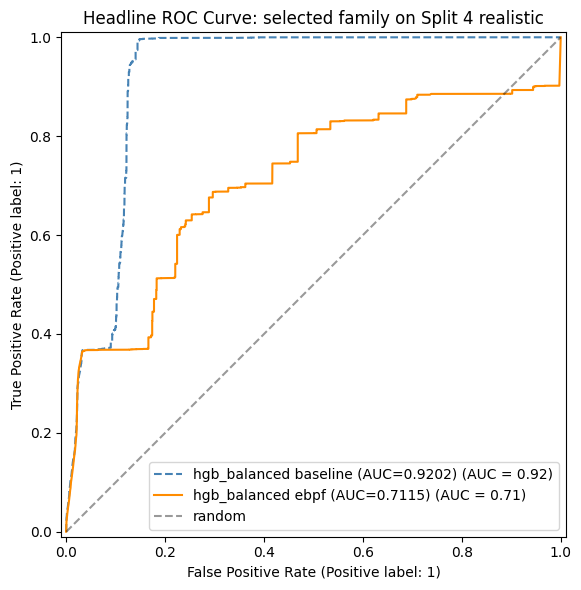

[+] Saved ROC plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/roc_hgb_split4_realistic_seed42.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

for fs_name, colour, ls in [('baseline', 'steelblue', '--'), ('ebpf', 'darkorange', '-')]:
    if fs_name not in headline_results:
        continue
    r = headline_results[fs_name]
    yt = np.array(r['y_test'])
    yp = np.array(r['y_prob'])
    auc = r['test']['roc_auc']
    RocCurveDisplay.from_predictions(
        yt, yp, ax=ax,
        name=f'{r["model_name"]} {fs_name} (AUC={auc:.4f})',
        color=colour, linestyle=ls,
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random')
ax.set_title('Headline ROC Curve: selected family on Split 4 realistic')
ax.legend()
plt.tight_layout()
out_png = REPORTS_DIR / f'roc_hgb_split4_realistic_seed{RANDOM_SEED}.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'[+] Saved ROC plot: {out_png}')


## Split 5 robustness metadata summary

Split 5 is a robustness split rather than a single headline test set. This cell summarises the fold metadata.


In [19]:
robustness_rows = []
for fs_name, split5_dir in [('baseline', SPLITS_5_BASELINE), ('ebpf', SPLITS_5_EBPF)]:
    meta_path = Path(split5_dir) / 'folds_meta.json'
    if not meta_path.exists():
        print(f'[!] Split 5 metadata not found for {fs_name}: {meta_path}')
        continue
    meta = json.loads(meta_path.read_text())
    folds = meta.get('folds', [])
    if not folds:
        print(f'[!] Split 5 metadata is empty for {fs_name}: {meta_path}')
        continue
    train_rows = [f['train_rows'] for f in folds]
    test_rows = [f['test_rows'] for f in folds]
    test_attacks = [f['test_attacks'] for f in folds]
    unseen_count = sum(1 for f in folds if f.get('unseen_in_train'))
    robustness_rows.append({
        'feature_set': fs_name,
        'n_folds': len(folds),
        'mean_train_rows': float(np.mean(train_rows)),
        'mean_test_rows': float(np.mean(test_rows)),
        'mean_test_attacks': float(np.mean(test_attacks)),
        'folds_with_unseen_families': int(unseen_count),
    })

robustness_df = pd.DataFrame(robustness_rows)
if not robustness_df.empty:
    print(robustness_df.to_string(index=False, float_format='{:.2f}'.format))
    robustness_csv = REPORTS_DIR / f'robustness_split5_metadata_seed{RANDOM_SEED}.csv'
    robustness_df.to_csv(robustness_csv, index=False)
    print(f'\n[+] Saved Split 5 metadata summary: {robustness_csv}')
else:
    print('[!] No Split 5 metadata available to summarize.')


feature_set  n_folds  mean_train_rows  mean_test_rows  mean_test_attacks  folds_with_unseen_families
   baseline       15       1692188.80       423047.20           89471.60                           9
       ebpf       15       1692188.80       423047.20           89471.60                           9

[+] Saved Split 5 metadata summary: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/robustness_split5_metadata_seed42.csv
